# Azerbaijan Financial Sector Macro Analysis
## World Bank Development Data Pipeline — Statistical Modelling & Machine Learning Report

**Data:** Central Bank of Azerbaijan (CBAR Statistical Bulletin),
World Bank Global Findex, World Bank API (GDP per capita)

**Period:**
- Azerbaijan banking & macro (monthly): 74 months through January 2026
- Azerbaijan macro indicators (annual): 32 years
- Global Findex: survey waves 2011, 2014, 2017, 2021 (771 country-wave observations)
- GDP per capita: 160+ countries, multi-decade panel (14,322 observations)

---

### Overview

This notebook presents an end-to-end quantitative analysis of Azerbaijan's financial sector, combining macroeconomic KPIs, econometric modelling, and machine learning.

| Step | Technique | Purpose |
|------|-----------|---------|
| 1 | KPI Design & Dashboard | Summarise sector health at a glance |
| 2 | Correlation Heatmap | Detect multicollinearity before modelling |
| 3 | Unit Root Tests (ADF) | Ensure stationarity before regression |
| 4 | OLS Regression + Diagnostics | Identify drivers of lending rates |
| 5 | Ridge / Lasso Regularisation | Reduce overfitting, rank feature importance |
| 6 | Granger Causality | Test directional predictive relationships |
| 7 | ARIMA Forecasting | Project credit growth over 12 months |
| 8 | Random Forest / GBM | Non-linear prediction of loan growth |
| 9 | Panel Regression (Findex) | Cross-country financial inclusion analysis |
| 10 | K-Means + PCA Clustering | Group countries by inclusion profile |
| 11 | Bootstrap CI | Robust inference on LDR mean |
| 12 | Chow Structural Break | Detect regime shift around 2015 currency crisis |

---


## 0. Setup & Imports

In [1]:
import warnings, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, silhouette_score

from scipy import stats

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'figure.figsize': (12, 5)})

# Paths — DATA_DIR points to outputs/tables from either project root or analysis/
_here = Path.cwd()
if (_here / 'outputs' / 'tables').exists():
    DATA_DIR = _here / 'outputs' / 'tables'
    OUT_DIR  = _here / 'outputs'
else:
    DATA_DIR = _here.parent / 'outputs' / 'tables'
    OUT_DIR  = _here.parent / 'outputs'

OUT_DIR.mkdir(exist_ok=True)
# print('DATA_DIR:', DATA_DIR)
# print('OUT_DIR: ', OUT_DIR)


## 1. Data Loading

Six datasets are loaded and lightly pre-processed:

- **Macro** — annual GDP growth, oil/non-oil split (CBA bulletins)
- **Banking** — monthly balance-sheet aggregates (loans, deposits, assets)
- **Interest Rates** — monthly AZN lending & deposit rates
- **Monetary Policy** — CBA refinancing rate (monthly)
- **NPL** — non-performing loan stocks (monthly)
- **Global Findex / GDP** — account ownership & income for 160+ countries


In [2]:
# ── Macro (annual) ────────────────────────────────────────────────────────────
macro_raw = pd.read_csv(DATA_DIR / 'aze_macro_main_periodic.csv',
                        parse_dates=['period_date'])
macro = (macro_raw[macro_raw['period_type'] == 'annual']
         .sort_values('period_date').reset_index(drop=True))
macro['year'] = macro['period_date'].dt.year

# ── Banking aggregates (monthly) ──────────────────────────────────────────────
banking = (pd.read_csv(DATA_DIR / 'aze_banking_monthly.csv', parse_dates=['month'])
           .sort_values('month').reset_index(drop=True))
banking.rename(columns={'month': 'date'}, inplace=True)

# ── Interest rates (monthly) ──────────────────────────────────────────────────
rates_raw = pd.read_csv(DATA_DIR / 'aze_interest_rates_periodic.csv',
                        parse_dates=['period_date'])
rates_monthly = (rates_raw[rates_raw['period_type'] == 'monthly']
                 .sort_values('period_date').reset_index(drop=True))
rates_monthly.rename(columns={'period_date': 'date'}, inplace=True)
rates_monthly = rates_monthly[
    rates_monthly['loan_avg_rate_azn_pct'].notna() &
    rates_monthly['deposit_avg_rate_azn_pct'].notna()].copy()

# ── Monetary policy (monthly) ─────────────────────────────────────────────────
policy = (pd.read_csv(DATA_DIR / 'aze_policy_rate_monthly.csv', parse_dates=['month'])
          .sort_values('month').reset_index(drop=True))
policy.rename(columns={'month': 'date'}, inplace=True)

# ── NPL (monthly) ─────────────────────────────────────────────────────────────
npl_raw = pd.read_csv(DATA_DIR / 'aze_npl_structure_periodic.csv',
                      parse_dates=['period_date'])
npl = (npl_raw[npl_raw['period_type'] == 'monthly']
       .sort_values('period_date').reset_index(drop=True))
npl.rename(columns={'period_date': 'date'}, inplace=True)

# ── Global Findex & GDP ───────────────────────────────────────────────────────
findex = pd.read_csv(DATA_DIR / 'global_findex_country_year.csv')
gdp_pc = pd.read_csv(DATA_DIR / 'gdp_per_capita_country_year.csv')

print(f"macro: {macro.shape}, banking: {banking.shape}, rates: {rates_monthly.shape}")
print(f"policy: {policy.shape}, npl: {npl.shape}")
print(f"findex: {findex.shape}, gdp_pc: {gdp_pc.shape}")


macro: (32, 23), banking: (74, 8), rates: (135, 20)
policy: (253, 8), npl: (50, 12)
findex: (771, 10), gdp_pc: (14322, 10)


## 2. KPI Design & Dashboard

Good KPI design translates raw balance-sheet data into **decision-relevant signals**.
The five indicators below collectively capture credit intermediation efficiency, asset quality, monetary transmission, and sector scale.

| KPI | Formula | Benchmark |
|-----|---------|-----------|
| Loan-to-Deposit Ratio (LDR) | Total Loans / Total Deposits | < 80 % (prudent) |
| NPL Ratio | NPL Stock / Total Loans | < 5 % (Basel III / prudential reference) |
| Interest Spread (AZN) | Avg Lending Rate − Avg Deposit Rate | < 8 % (analytical warning) |
| Loan Growth MoM | Δ Loans / Loans(t-1) | > 0 % (simple directional benchmark) |
| Non-Oil GDP Share | Non-Oil GDP / Total GDP | > 30 % (diversification) |

---
### KPI construction notes

The scorecard uses the latest available readings from the banking, rates, NPL, macro, and policy tables.

- **LDR (Loan-to-Deposit Ratio):** calculated as total bank loans divided by total bank deposits, multiplied by 100.
- **Loan Growth MoM:** monthly percentage change in total bank loans.
- **Interest Spread (AZN):** average AZN lending rate minus average AZN deposit rate.
- **NPL Ratio:** total non-performing loans divided by total bank loans, multiplied by 100.
- **Non-Oil GDP Share:** non-oil GDP divided by nominal GDP, multiplied by 100.
- **Policy Rate:** latest CBA refinancing rate.

For scorecard use, each KPI is reduced to its **latest non-null observation**.

In [3]:
# LDR and loan growth
banking['ldr'] = (banking['bank_loans_customers_mn_azn'] /
                  banking['bank_deposits_total_mn_azn'] * 100)
banking['loan_growth_mom'] = banking['bank_loans_customers_mn_azn'].pct_change() * 100

# Interest spread
rates_monthly['interest_spread_azn'] = (rates_monthly['loan_avg_rate_azn_pct'] -
                                         rates_monthly['deposit_avg_rate_azn_pct'])

# NPL ratio  — merge NPL stock with loan stock
npl_merged = npl.merge(banking[['date','bank_loans_customers_mn_azn']], on='date', how='left')
npl_merged['npl_ratio_pct'] = (npl_merged['npl_total_mn_azn'] /
                                npl_merged['bank_loans_customers_mn_azn'] * 100)

# Macro KPIs
macro['non_oil_gdp_share'] = (macro['non_oil_gdp_mn_azn'] /
                               macro['nominal_gdp_mn_azn'] * 100)

# Latest readings for scorecard
latest_ldr    = banking['ldr'].dropna().iloc[-1]
latest_npl    = npl_merged['npl_ratio_pct'].dropna().iloc[-1]
latest_spread = rates_monthly['interest_spread_azn'].dropna().iloc[-1]
latest_loans  = banking['bank_loans_customers_mn_azn'].dropna().iloc[-1]
latest_growth = banking['loan_growth_mom'].dropna().iloc[-1]
latest_policy = policy['refinancing_rate'].dropna().iloc[-1]
latest_gdp    = macro['real_gdp_growth_pct'].dropna().iloc[-1]
latest_nonoil = macro['non_oil_gdp_share'].dropna().iloc[-1]

print(f"LDR: {latest_ldr:.1f}%  |  NPL: {latest_npl:.2f}%  |  Spread: {latest_spread:.2f}%  |  Policy: {latest_policy:.1f}%")


LDR: 81.5%  |  NPL: 2.65%  |  Spread: 6.21%  |  Policy: 6.8%


### KPI Dashboard

Each panel displays the historical trend of one KPI. Horizontal dashed lines mark the relevant benchmark threshold.


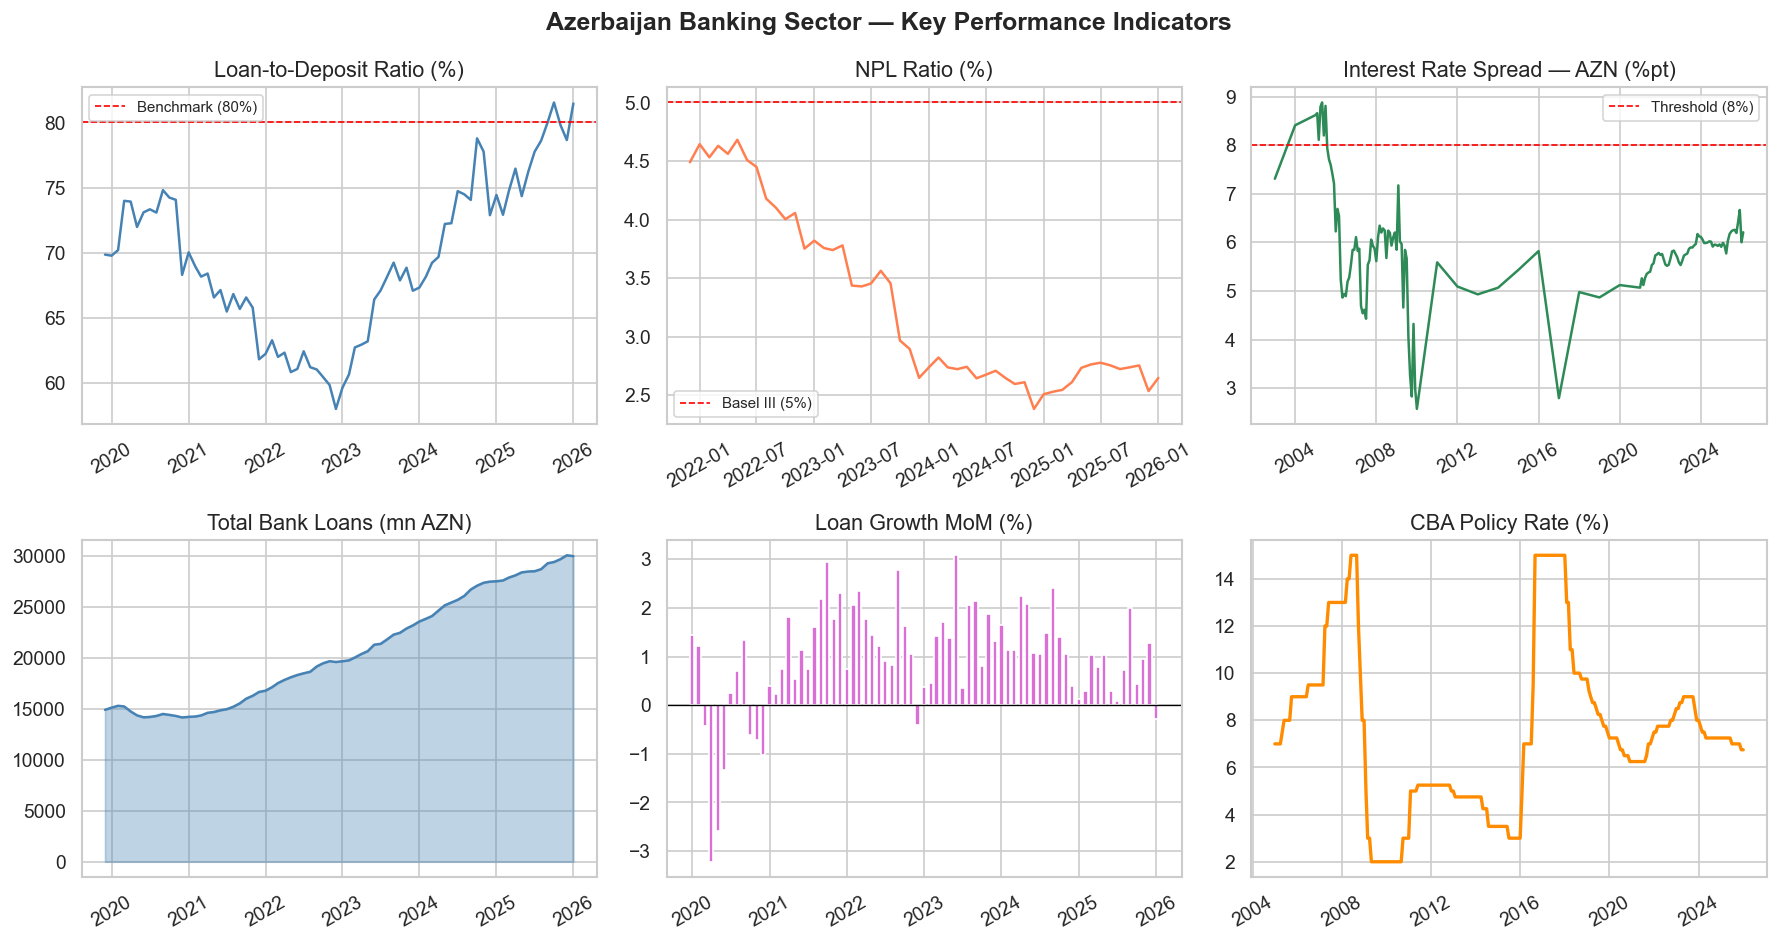

Saved: kpi_dashboard.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Azerbaijan Banking Sector — Key Performance Indicators', fontsize=15, fontweight='bold')
axes = axes.flatten()

ax = axes[0]
ax.plot(banking['date'], banking['ldr'], color='steelblue')
ax.axhline(80, color='red', linestyle='--', linewidth=1, label='Benchmark (80%)')
ax.set_title('Loan-to-Deposit Ratio (%)')
ax.legend(fontsize=9); ax.tick_params(axis='x', rotation=30)

ax = axes[1]
ax.plot(npl_merged['date'], npl_merged['npl_ratio_pct'], color='coral')
ax.axhline(5, color='red', linestyle='--', linewidth=1, label='Basel III (5%)')
ax.set_title('NPL Ratio (%)')
ax.legend(fontsize=9); ax.tick_params(axis='x', rotation=30)

ax = axes[2]
ax.plot(rates_monthly['date'], rates_monthly['interest_spread_azn'], color='seagreen')
ax.axhline(8, color='red', linestyle='--', linewidth=1, label='Threshold (8%)')
ax.set_title('Interest Rate Spread — AZN (%pt)')
ax.legend(fontsize=9); ax.tick_params(axis='x', rotation=30)

ax = axes[3]
ax.fill_between(banking['date'], banking['bank_loans_customers_mn_azn'], alpha=0.35, color='steelblue')
ax.plot(banking['date'], banking['bank_loans_customers_mn_azn'], color='steelblue')
ax.set_title('Total Bank Loans (mn AZN)'); ax.tick_params(axis='x', rotation=30)

ax = axes[4]
ax.bar(banking['date'], banking['loan_growth_mom'], color='orchid', width=20)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Loan Growth MoM (%)'); ax.tick_params(axis='x', rotation=30)

ax = axes[5]
ax.plot(policy['date'], policy['refinancing_rate'], color='darkorange', linewidth=2)
ax.set_title('CBA Policy Rate (%)'); ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(OUT_DIR / 'kpi_dashboard.png', bbox_inches='tight')
plt.show()
print('Saved: kpi_dashboard.png')


### KPI dashboard interpretation

The six-panel KPI dashboard provides a compact view of Azerbaijan’s banking-sector conditions.

- **LDR** has risen above the 80% benchmark, suggesting tighter funding capacity for further rapid loan expansion.
- **NPL ratio** has declined and remains below the 5% reference level, indicating relatively contained asset-quality stress.
- **Interest spread** remains below the 8% warning threshold, although borrowing costs may still be meaningful for MSMEs.
- **Total bank loans** continue to trend upward over the medium term.
- **Loan growth MoM** shows weaker short-run momentum, with recent readings near zero or slightly negative.
- **The CBA policy rate** provides macro-financial context, but should not be interpreted mechanically as a direct driver of lending conditions in every period.

Overall, the dashboard points to a banking system that remains broadly stable, but may now be operating with tighter funding conditions and less room for additional rapid credit expansion.

## 3. Correlation Analysis

Before fitting any regression, it is important to understand the **pairwise linear relationships** among candidate features. A correlation heatmap reveals potential multicollinearity — when two predictors carry largely the same information, inflating standard errors and making coefficient estimates unreliable.

**Reading the heatmap:** values near ±1 indicate near-perfect linear correlation; values near 0 indicate independence. Pairs with |r| > 0.8 deserve scrutiny in regression.


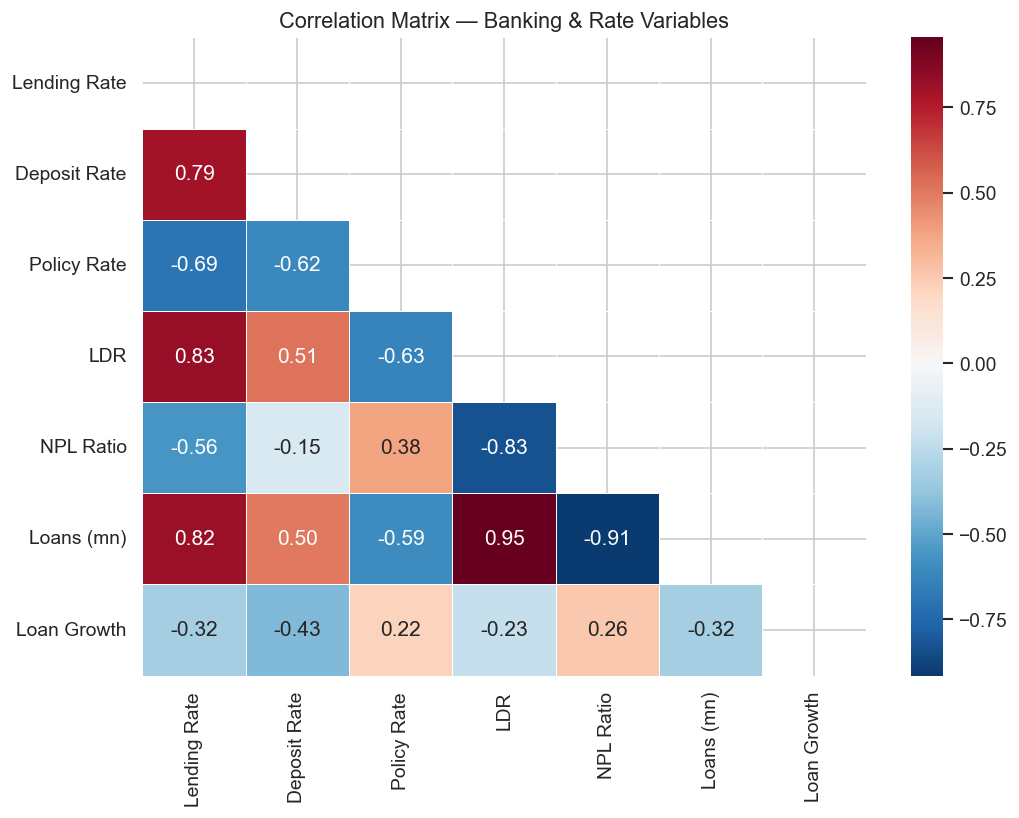

Saved: correlation_heatmap.png


In [5]:
merged = (rates_monthly[['date','loan_avg_rate_azn_pct','deposit_avg_rate_azn_pct']]
          .merge(policy[['date','refinancing_rate']], on='date', how='left')
          .merge(banking[['date','ldr','bank_loans_customers_mn_azn','loan_growth_mom']], on='date', how='left')
          .merge(npl_merged[['date','npl_ratio_pct']], on='date', how='left'))

cols = ['loan_avg_rate_azn_pct','deposit_avg_rate_azn_pct',
        'refinancing_rate','ldr','npl_ratio_pct',
        'bank_loans_customers_mn_azn','loan_growth_mom']
corr_df = merged[cols].dropna()

labels = ['Lending Rate','Deposit Rate','Policy Rate','LDR','NPL Ratio','Loans (mn)','Loan Growth']
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones(len(cols), dtype=bool))
sns.heatmap(corr_df.rename(columns=dict(zip(cols, labels))).corr(),
            annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix — Banking & Rate Variables')
plt.tight_layout()
plt.savefig(OUT_DIR / 'correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: correlation_heatmap.png')


### Interpretation

The correlation heatmap provides a quick overview of how key banking and rate variables move together over time.

Several relationships stand out:

- **Lending rates** are strongly positively correlated with both **deposit rates** and **LDR**, suggesting that tighter funding conditions are associated with higher borrowing costs.
- **Total loans** are strongly positively correlated with **LDR** and strongly negatively correlated with the **NPL ratio**, reflecting the broad shift toward higher loan volumes alongside improving asset-quality ratios.
- **Loan growth** shows only weak to moderate correlations with the other variables, which is consistent with the idea that short-run month-on-month credit growth is relatively noisy and difficult to explain.
- The negative correlation between the **policy rate** and the **lending rate** should be interpreted cautiously, since full-sample correlations may be distorted by structural breaks and changing monetary-transmission dynamics over time.

Overall, the heatmap is useful as an exploratory diagnostic, but it should be read together with the regression and structural-break results rather than as evidence of causal relationships.

## 4. Stationarity Testing — Augmented Dickey-Fuller (ADF)

Most macroeconomic and financial time series contain a **unit root** — their level drifts over time rather than returning to a fixed mean. Regressing two non-stationary series produces **spurious correlations** (high R² even when the series are unrelated), a well-known pitfall called spurious regression (Granger & Newbold, 1974).

The ADF test formally tests:
> **H₀:** The series has a unit root (non-stationary)  
> **H₁:** The series is stationary

If p-value < 0.05, the series is stationary. If stationary only after first-differencing, it is **I(1)**.


In [6]:
adf_series = {
    'Bank Loans'      : banking['bank_loans_customers_mn_azn'].dropna(),
    'LDR'             : banking['ldr'].dropna(),
    'Loan Growth MoM' : banking['loan_growth_mom'].dropna(),
    'Lending Rate'    : merged['loan_avg_rate_azn_pct'].dropna(),
    'Policy Rate'     : merged['refinancing_rate'].dropna(),
    'NPL Ratio'       : npl_merged['npl_ratio_pct'].dropna(),
}

print(f"{'Series':<25} {'ADF Stat':>10} {'p-value':>10} {'Stationary':>15}")
print('-' * 63)
for name, series in adf_series.items():
    stat, p, *_ = adfuller(series, autolag='AIC')
    label = 'YES' if p < 0.05 else 'NO (unit root)'
    print(f"{name:<25} {stat:>10.4f} {p:>10.4f} {label:>15}")


Series                      ADF Stat    p-value      Stationary
---------------------------------------------------------------
Bank Loans                    1.1260     0.9954  NO (unit root)
LDR                          -1.2224     0.6639  NO (unit root)
Loan Growth MoM              -4.1918     0.0007             YES
Lending Rate                 -1.3438     0.6089  NO (unit root)
Policy Rate                  -2.2659     0.1832  NO (unit root)
NPL Ratio                    -1.3988     0.5829  NO (unit root)


### Interpretation

The ADF results suggest that most level variables in the banking dataset are **non-stationary**, including **bank loans, LDR, lending rates, policy rates, and the NPL ratio**. By contrast, **month-on-month loan growth** is stationary.

This matters statistically because regressions using non-stationary level series can produce **spurious relationships**, with high apparent fit but weak economic meaning. In practical terms, the result suggests that many banking-sector indicators in Azerbaijan do not simply fluctuate around a stable long-run mean; instead, they appear to shift across periods, likely reflecting structural change, crisis effects, and changing monetary conditions.

For modeling, this means that **growth rates, first differences, or break-aware specifications** are generally more appropriate than simple full-sample regressions in levels. The result is also consistent with the broader narrative of the dataset: Azerbaijan’s banking environment appears to have evolved through regime shifts rather than through small stationary fluctuations around a fixed equilibrium.

## 5. OLS Regression — Drivers of Lending Rates

**Research question:** What determines the average AZN lending rate?

$$\text{Lending Rate}_t = \beta_0 + \beta_1 \cdot \text{Deposit Rate}_t + \beta_2 \cdot \text{Policy Rate}_t + \beta_3 \cdot \text{NPL Ratio}_t + \beta_4 \cdot \text{LDR}_t + \varepsilon_t$$

**Why these predictors?**
- *Deposit rate*: the marginal cost of funds; should pass through positively.
- *Policy rate*: CBA refinancing rate signals the monetary policy stance.
- *NPL ratio*: higher credit risk should induce wider risk premia.
- *LDR*: tighter liquidity may force higher lending rates.

**Diagnostics:**
- **R² / Adj-R²** — overall model fit
- **VIF** — detect multicollinearity (VIF > 10 is concerning)
- **Durbin-Watson** — detect serial autocorrelation in residuals (2 = none)


In [7]:
ols_data = merged[['loan_avg_rate_azn_pct','deposit_avg_rate_azn_pct',
                    'refinancing_rate','npl_ratio_pct','ldr']].dropna()

y = ols_data['loan_avg_rate_azn_pct']
X = sm.add_constant(ols_data[['deposit_avg_rate_azn_pct',
                               'refinancing_rate','npl_ratio_pct','ldr']])

model_ols = sm.OLS(y, X).fit()
print(model_ols.summary())

print("\nVariance Inflation Factors:")
vif_df = pd.DataFrame({
    'Variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif_df.to_string(index=False))
print(f"\nDurbin-Watson: {sm.stats.durbin_watson(model_ols.resid):.3f}")


                              OLS Regression Results                             
Dep. Variable:     loan_avg_rate_azn_pct   R-squared:                       0.872
Model:                               OLS   Adj. R-squared:                  0.860
Method:                    Least Squares   F-statistic:                     76.34
Date:                   Sun, 12 Apr 2026   Prob (F-statistic):           1.82e-19
Time:                           21:26:34   Log-Likelihood:                 29.306
No. Observations:                     50   AIC:                            -48.61
Df Residuals:                         45   BIC:                            -39.05
Df Model:                              4                                         
Covariance Type:               nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

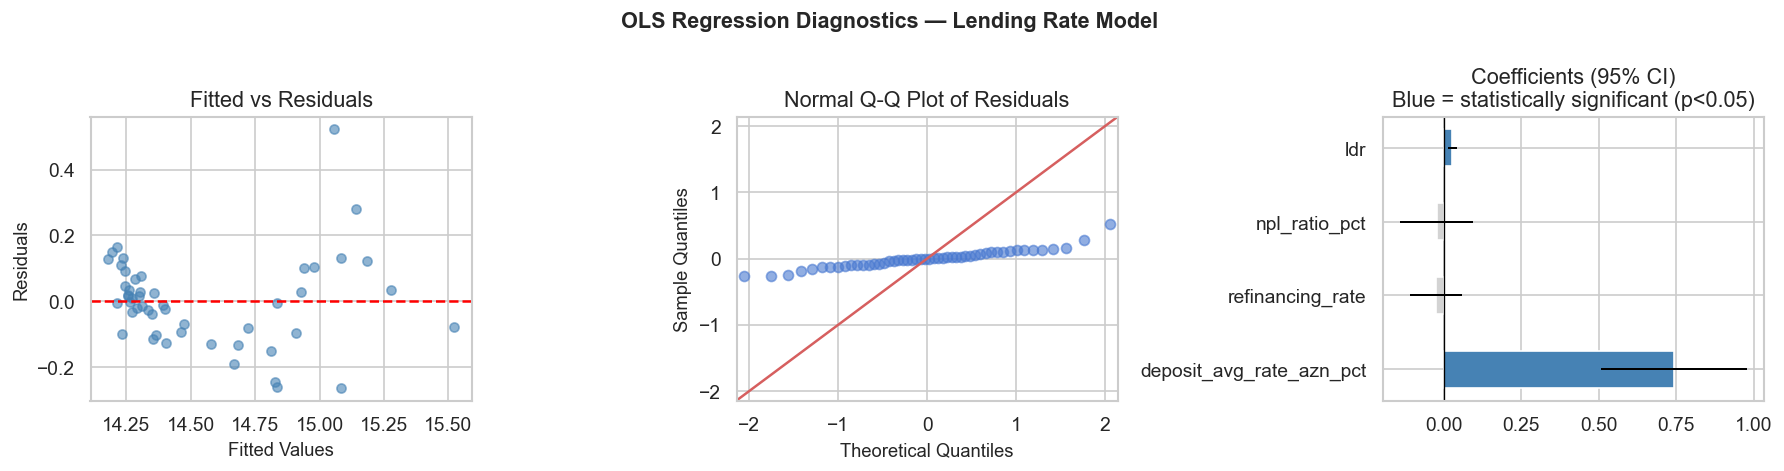

Saved: ols_diagnostics.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('OLS Regression Diagnostics — Lending Rate Model', fontsize=13, fontweight='bold')

axes[0].scatter(model_ols.fittedvalues, model_ols.resid, alpha=0.6, color='steelblue', s=30)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values'); axes[0].set_ylabel('Residuals')
axes[0].set_title('Fitted vs Residuals')

sm.qqplot(model_ols.resid, line='45', ax=axes[1], alpha=0.6)
axes[1].set_title('Normal Q-Q Plot of Residuals')

coefs  = model_ols.params.drop('const')
errors = model_ols.bse.drop('const')
colors = ['steelblue' if model_ols.pvalues[c] < 0.05 else 'lightgrey' for c in coefs.index]
axes[2].barh(coefs.index, coefs, xerr=1.96*errors, color=colors,
             error_kw={'elinewidth':1.2,'ecolor':'black'}, height=0.5)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('Coefficients (95% CI)\nBlue = statistically significant (p<0.05)')

plt.tight_layout()
plt.savefig(OUT_DIR / 'ols_diagnostics.png', bbox_inches='tight')
plt.show()
print('Saved: ols_diagnostics.png')


### Interpretation

The OLS results suggest that **deposit rates** and **LDR** are the two most important correlates of AZN lending rates in this sample. The deposit-rate coefficient is large and highly significant, indicating that higher bank funding costs are associated with higher lending rates. LDR is also positive and statistically significant, which is consistent with the idea that tighter balance-sheet funding conditions can put upward pressure on borrowing costs.

By contrast, the **policy rate** and **NPL ratio** are not statistically significant once the other variables are included. This suggests that, in the current specification, lending rates are more closely aligned with banks’ funding conditions than with the policy rate alone.

**Limitation:** However, the diagnostics also indicate caution. Residual normality is weak, the **Durbin-Watson statistic (0.875)** suggests positive serial correlation, and the model is estimated in levels despite earlier evidence that several series are non-stationary. The regression is therefore useful as an exploratory benchmark, but not as a fully reliable structural model.

**Practical meaning:** For firms and households, especially MSMEs, this implies that lending conditions may depend less on the headline policy rate and more on whether banks are facing higher deposit costs and tighter funding capacity.

## 6. Regularisation — Ridge, Lasso & Elastic Net

OLS minimises the sum of squared residuals without constraining coefficient size. When predictors are correlated, coefficients can be large and unstable. **Regularisation** adds a penalty that shrinks coefficients, trading a small amount of bias for a large reduction in variance.

| Method | Penalty | Effect |
|--------|---------|--------|
| **Ridge (L2)** | λ∑βⱼ² | Shrinks all coefficients; never sets any to exactly zero |
| **Lasso (L1)** | λ∑\|βⱼ\| | Automatic variable selection — sets small coefficients to zero |
| **Elastic Net** | α·L1 + (1-α)·L2 | Hybrid: combines Ridge grouping with Lasso sparsity |

We use **TimeSeriesSplit** CV (5 folds) — training always precedes validation, preventing look-ahead bias.


Model             CV R2 Mean    CV R2 Std
------------------------------------------
OLS                 -14.2874      20.5291
Ridge(1)             -3.0953       2.1479
Lasso(0.1)           -8.1880       8.9037
ElasticNet           -6.4457       5.8171


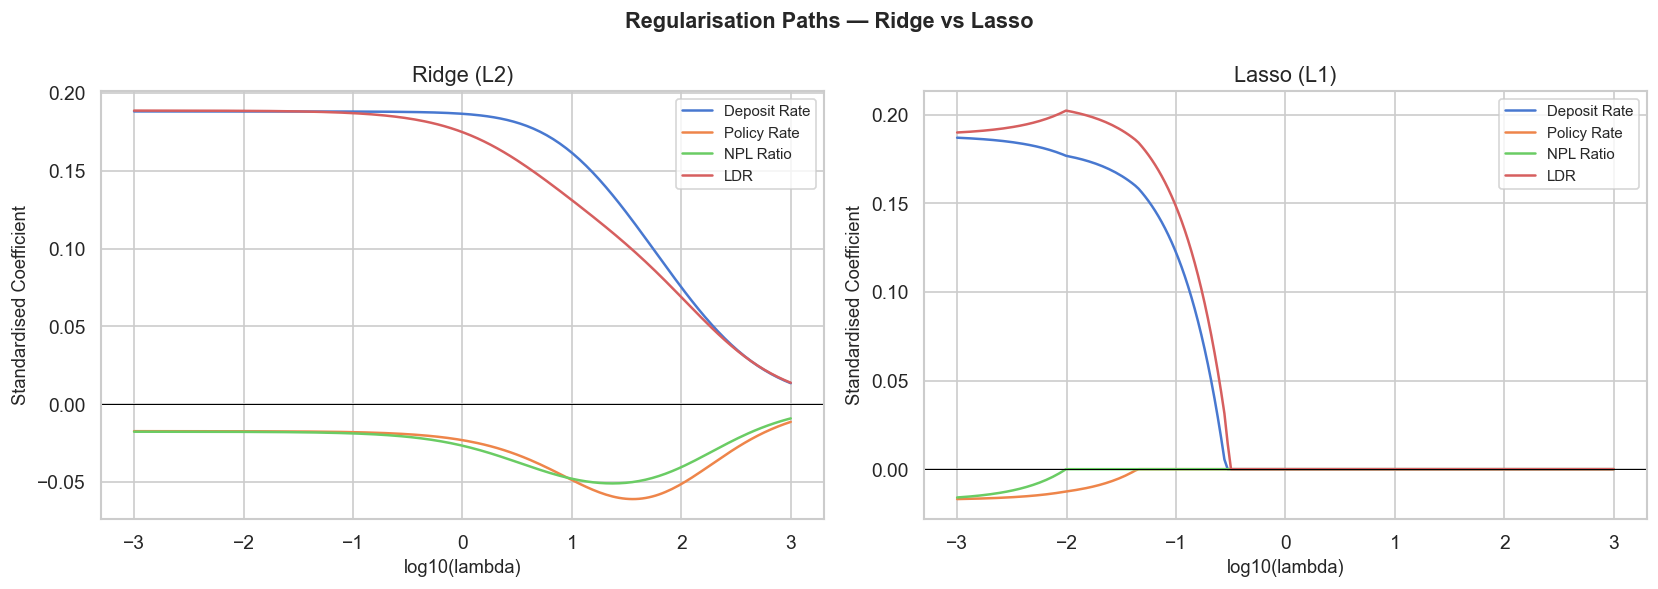

Saved: regularization_paths.png


In [9]:
scaler = StandardScaler()
X_sc = scaler.fit_transform(X.drop(columns='const'))
y_arr = y.values

tscv = TimeSeriesSplit(n_splits=5)
reg_models = {
    'OLS'        : LinearRegression(),
    'Ridge(1)'   : Ridge(alpha=1.0),
    'Lasso(0.1)' : Lasso(alpha=0.1),
    'ElasticNet' : ElasticNet(alpha=0.1, l1_ratio=0.5),
}

print(f"{'Model':<15} {'CV R2 Mean':>12} {'CV R2 Std':>12}")
print('-' * 42)
for name, mdl in reg_models.items():
    scores = cross_val_score(mdl, X_sc, y_arr, cv=tscv, scoring='r2')
    print(f"{name:<15} {scores.mean():>12.4f} {scores.std():>12.4f}")

# Regularisation paths
alphas = np.logspace(-3, 3, 200)
ridge_coefs = [Ridge(alpha=a).fit(X_sc, y_arr).coef_ for a in alphas]
lasso_coefs = [Lasso(alpha=a, max_iter=5000).fit(X_sc, y_arr).coef_ for a in alphas]
feature_names = ['Deposit Rate', 'Policy Rate', 'NPL Ratio', 'LDR']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Regularisation Paths — Ridge vs Lasso', fontsize=13, fontweight='bold')
for i, name in enumerate(feature_names):
    axes[0].plot(np.log10(alphas), [c[i] for c in ridge_coefs], label=name)
    axes[1].plot(np.log10(alphas), [c[i] for c in lasso_coefs], label=name)
for ax, title in zip(axes, ['Ridge (L2)', 'Lasso (L1)']):
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_xlabel('log10(lambda)'); ax.set_ylabel('Standardised Coefficient')
    ax.set_title(title); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'regularization_paths.png', bbox_inches='tight')
plt.show()
print('Saved: regularization_paths.png')


### Interpretation

**Cross-validation performance:** All models return negative CV R²
under TimeSeriesSplit. This is a known consequence of applying
level-series models across structural regime changes (notably the
2015 currency crisis): coefficients estimated on an earlier sub-period
do not generalise to a later one. This result motivates the structural
break test in Section 13.

**Regularisation paths — key findings:**

| Variable | Ridge | Lasso | Interpretation |
|---|---|---|---|
| Deposit Rate | Last to shrink | Last to reach zero | Dominant and robust predictor |
| LDR | Shrinks with Deposit Rate | Reaches zero at λ ≈ 0.3 | Secondary predictor |
| Policy Rate | Slowly approaches zero | Reaches zero early (λ ≈ 0.1) | Weak — consistent with OLS |
| NPL Ratio | Near zero throughout | First to reach zero | Not a meaningful predictor |

Lasso's variable selection confirms the OLS finding: the deposit rate
is the primary structural driver of AZN lending rates. The policy rate
and NPL ratio carry no incremental explanatory power once deposit
market conditions are controlled for.

> **Implication for monetary policy:** The CBA refinancing rate does not
> directly anchor retail lending rates in this sample. Banks appear to
> price loans off their funding costs (deposit rates) rather than off
> the central bank signal — consistent with a bank-dominated financial
> system where the monetary transmission mechanism operates with a lag
> and through indirect channels.   
> This motivates the Granger causality
> test (Does the policy rate at least *precede* lending rate changes over
> time?) in Section 7. 

## 7. Granger Causality — Does the Policy Rate Drive Lending Rates?

A key question for monetary policy effectiveness is whether CBA policy rate changes **propagate through** to retail lending rates. Granger causality tests predictive precedence:

> **H₀:** Past values of X do NOT help predict Y (beyond Y's own lags)
> **H₁:** Past values of X DO improve the forecast of Y

**Important:** Granger causality is about *predictive precedence*, not structural causality. A significant result means "X contains information about the future of Y".

Since both series are I(1), we first-difference them before testing to satisfy the stationarity requirement.


Granger Causality: Policy Rate -> Lending Rate
H0: Policy rate does NOT Granger-cause lending rate

Lag        F-stat    p-value               Decision
----------------------------------------------------
1         10.3396     0.0017     REJECT H0 (causal)
2          4.3996     0.0143     REJECT H0 (causal)
3          2.8955     0.0380     REJECT H0 (causal)
4          2.9823     0.0219     REJECT H0 (causal)


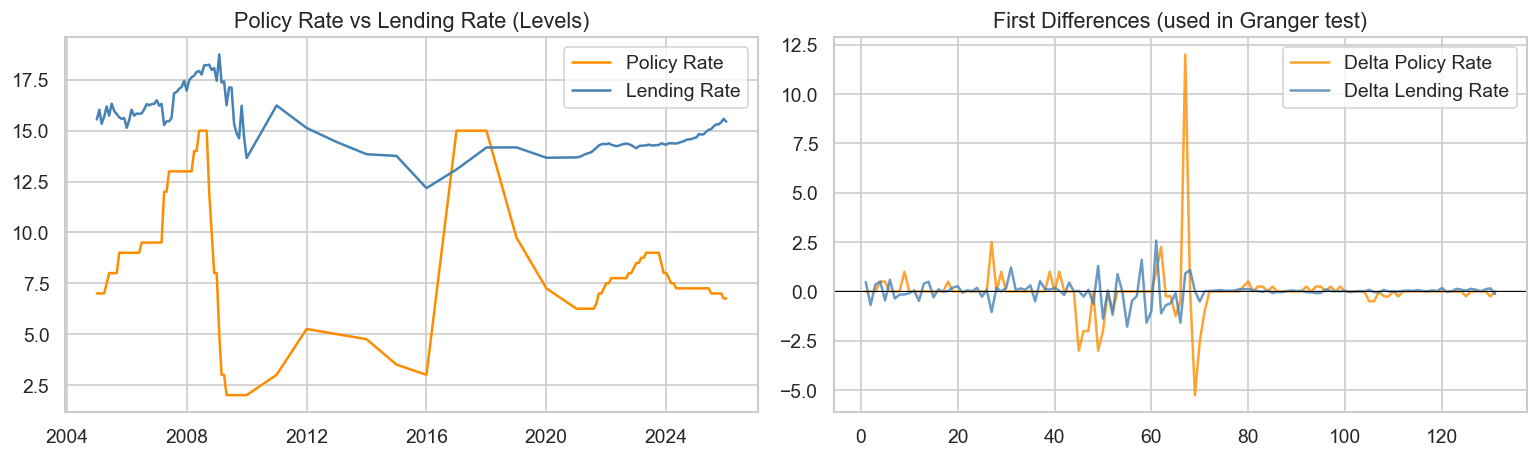

Saved: granger_causality.png


In [10]:
granger_df = merged[['date','loan_avg_rate_azn_pct','refinancing_rate']].dropna().reset_index(drop=True)
granger_diff = granger_df[['loan_avg_rate_azn_pct','refinancing_rate']].diff().dropna()

print("Granger Causality: Policy Rate -> Lending Rate")
print("H0: Policy rate does NOT Granger-cause lending rate")
results = grangercausalitytests(
    granger_diff[['loan_avg_rate_azn_pct','refinancing_rate']], maxlag=4, verbose=False)

print(f"\n{'Lag':<6} {'F-stat':>10} {'p-value':>10} {'Decision':>22}")
print('-' * 52)
for lag, res in results.items():
    F = res[0]['ssr_ftest'][0]; p = res[0]['ssr_ftest'][1]
    dec = 'REJECT H0 (causal)' if p < 0.05 else 'Fail to reject H0'
    print(f"{lag:<6} {F:>10.4f} {p:>10.4f} {dec:>22}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(granger_df['date'], granger_df['refinancing_rate'],
             label='Policy Rate', color='darkorange')
axes[0].plot(granger_df['date'], granger_df['loan_avg_rate_azn_pct'],
             label='Lending Rate', color='steelblue')
axes[0].set_title('Policy Rate vs Lending Rate (Levels)'); axes[0].legend()

axes[1].plot(granger_diff.index, granger_diff['refinancing_rate'],
             label='Delta Policy Rate', color='darkorange', alpha=0.8)
axes[1].plot(granger_diff.index, granger_diff['loan_avg_rate_azn_pct'],
             label='Delta Lending Rate', color='steelblue', alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.6)
axes[1].set_title('First Differences (used in Granger test)'); axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'granger_causality.png', bbox_inches='tight')
plt.show()
print('Saved: granger_causality.png')


### Interpretation

Changes in the CBAR policy rate Granger-cause changes in lending
rates at all lags 1–4 (all p < 0.05).

| Section | Method | Result |
|---|---|---|
| 5 | OLS (levels) | Policy rate not significant contemporaneously |
| 6 | Lasso | Policy rate zeroed out first |
| 7 | Granger (differences) | Policy rate significant at lags 1–4 |

These results are consistent: the policy rate does not determine
lending rates at the same point in time, but shifts in the policy
rate do lead shifts in lending rates by one to four months — the
monetary transmission channel operating with a lag.

> **CPF implication:** Delayed pass-through limits the short-run
> effectiveness of monetary policy as a countercyclical tool — a
> structural feature of Azerbaijan's bank-dominated financial system.

## 8. ARIMA Forecasting — Bank Loan Stock

**ARIMA(p, d, q)** captures the linear autocorrelation structure of a time series:

- **p** (AR order): how many lagged values explain the current value
- **d** (differencing): how many times to difference to achieve stationarity
- **q** (MA order): how many lagged forecast errors enter the model

Since bank loans are I(1), d = 1. We select p and q by minimising **AIC** (Akaike Information Criterion), which penalises model complexity.

The model is trained on all data except the final 12 months — the hold-out test set for evaluating out-of-sample forecast accuracy.


Best order: ARIMA(3, 1, 3), AIC = 811.57
Test RMSE: 241 mn AZN  |  MAE: 194 mn AZN  |  MAPE: 0.7%


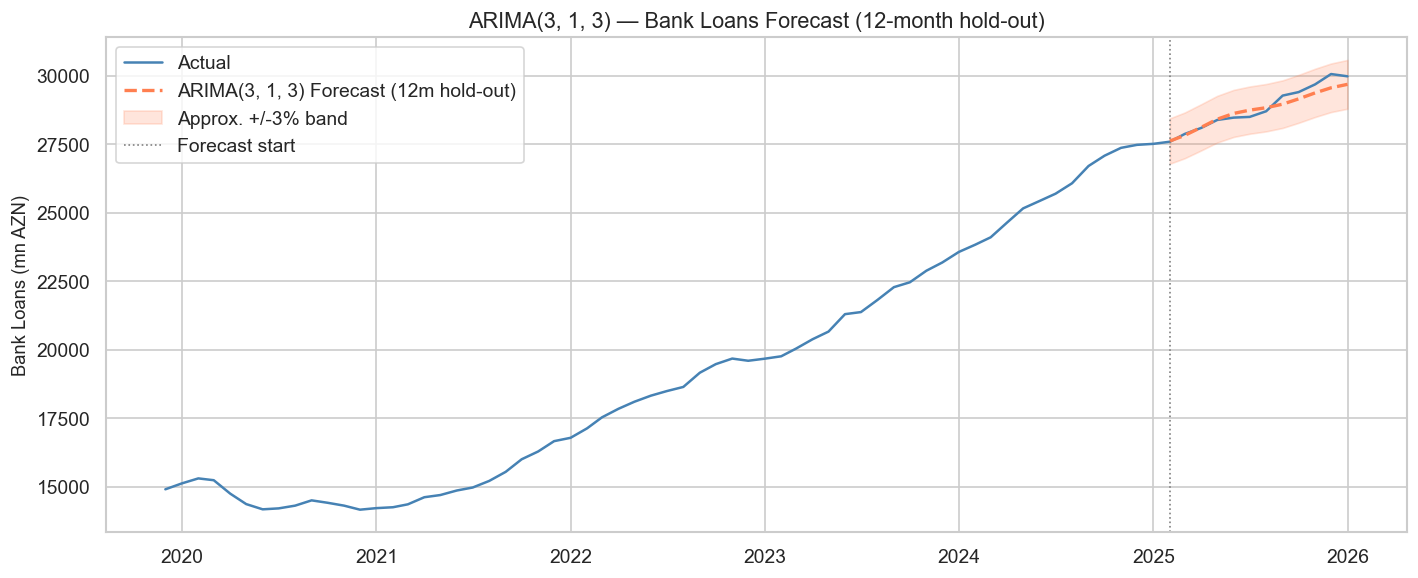

Saved: arima_forecast.png


In [13]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

loans_ts = (banking[['date','bank_loans_customers_mn_azn']].dropna()
            .set_index('date').squeeze())

# Set monthly frequency if inferrable
try:
    inferred = pd.infer_freq(loans_ts.index)
    if inferred:
        loans_ts = loans_ts.asfreq(inferred)
except Exception:
    pass

train, test = loans_ts.iloc[:-12], loans_ts.iloc[-12:]

best_aic, best_order = np.inf, (1, 1, 1)
for p in range(0, 4):
    for q in range(0, 4):
        try:
            aic = ARIMA(train, order=(p, 1, q)).fit().aic
            if aic < best_aic:
                best_aic, best_order = aic, (p, 1, q)
        except Exception:
            pass

print(f"Best order: ARIMA{best_order}, AIC = {best_aic:.2f}")
model_arima = ARIMA(train, order=best_order).fit()
forecast = model_arima.forecast(steps=12)

rmse = np.sqrt(mean_squared_error(test.values, forecast.values))
mae  = mean_absolute_error(test.values, forecast.values)
mape = np.mean(np.abs((test.values - forecast.values) / test.values)) * 100
print(f"Test RMSE: {rmse:,.0f} mn AZN  |  MAE: {mae:,.0f} mn AZN  |  MAPE: {mape:.1f}%")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(loans_ts.index, loans_ts.values, label='Actual', color='steelblue')
ax.plot(test.index, forecast.values, label=f'ARIMA{best_order} Forecast (12m hold-out)',
        color='coral', linestyle='--', linewidth=2)
ax.fill_between(test.index, forecast.values*0.97, forecast.values*1.03,
                alpha=0.2, color='coral', label='Approx. +/-3% band')
ax.axvline(test.index[0], color='grey', linestyle=':', linewidth=1, label='Forecast start')
ax.set_title(f'ARIMA{best_order} — Bank Loans Forecast (12-month hold-out)')
ax.set_ylabel('Bank Loans (mn AZN)'); ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'arima_forecast.png', bbox_inches='tight')
plt.show()
print('Saved: arima_forecast.png')


### Interpretation

**Model selection:** The preferred specification is **ARIMA(3,1,3)**, selected by **AIC** (**811.57**). This is consistent with treating the bank-loan stock series as approximately **I(1)**, so first differencing (**d = 1**) is used to model changes rather than levels. The AR(3) and MA(3) terms suggest that monthly credit growth exhibits meaningful short-run persistence in both past movements and past forecast errors.

**Forecast performance:** On the **12-month hold-out sample**, the model achieves an **RMSE of about 241 million AZN**, an **MAE of about 194 million AZN**, and a **MAPE of 0.7%**. This indicates that the model tracks the short-run upward trend in bank lending quite closely over the evaluation window.

**Uncertainty:** The forecast remains close to the realized path during the hold-out period, although uncertainty naturally increases with the forecast horizon. Given the relatively short sample (**about 74 monthly observations**), this should be interpreted as a **strong univariate benchmark** rather than a fully structural forecasting model.

**Limitation and next step:** Because this is a **univariate ARIMA**, it extrapolates only from the historical dynamics of bank loans and cannot directly anticipate external shocks or policy regime changes, such as oil-price declines, abrupt monetary tightening, or banking-sector stress. A natural next step would be to estimate an **ARIMAX** model with macro-financial covariates (for example, policy rates, inflation, deposits, or FX conditions), or a **VAR** model to capture the joint dynamics of lending and its drivers more explicitly.

## 9. Machine Learning — Predicting Loan Growth

While ARIMA captures linear autocorrelation, tree-based ensemble methods can detect **non-linear interactions** between predictors. We frame loan growth prediction as a supervised regression problem.

**Feature engineering (lag-based):**
- Lagged loan growth (1, 2, 3 months)
- Lagged policy rate (1, 2, 3 months)
- Lagged LDR (1, 2, 3 months)

Using lags ensures the model only uses information available *at prediction time*, preventing look-ahead bias. TimeSeriesSplit cross-validation further guards against data leakage.


=== Raw merged data condition ===
Rows before lagging: 62
Columns used: ['loan_growth_mom', 'refinancing_rate', 'ldr']
Index range: 72 -> 133

Missing values before lagging:
loan_growth_mom     0
refinancing_rate    0
ldr                 0
dtype: int64

Number of features: 9
Feature columns:
['loan_growth_mom_lag1', 'loan_growth_mom_lag2', 'loan_growth_mom_lag3', 'refinancing_rate_lag1', 'refinancing_rate_lag2', 'refinancing_rate_lag3', 'ldr_lag1', 'ldr_lag2', 'ldr_lag3']
X shape: (59, 9)
y shape: (59,)

=== TimeSeriesSplit condition ===
Number of splits: 5

Model                  CV R2 Mean    CV R2 Std
----------------------------------------------
RandomForest              -0.4712       0.4226
GradientBoosting          -0.8293       0.7627

=== Hold-out split condition ===
Train rows: 47
Test rows : 12
Train ratio: 79.7%
Test ratio : 20.3%

Random Forest hold-out R2: -0.8380


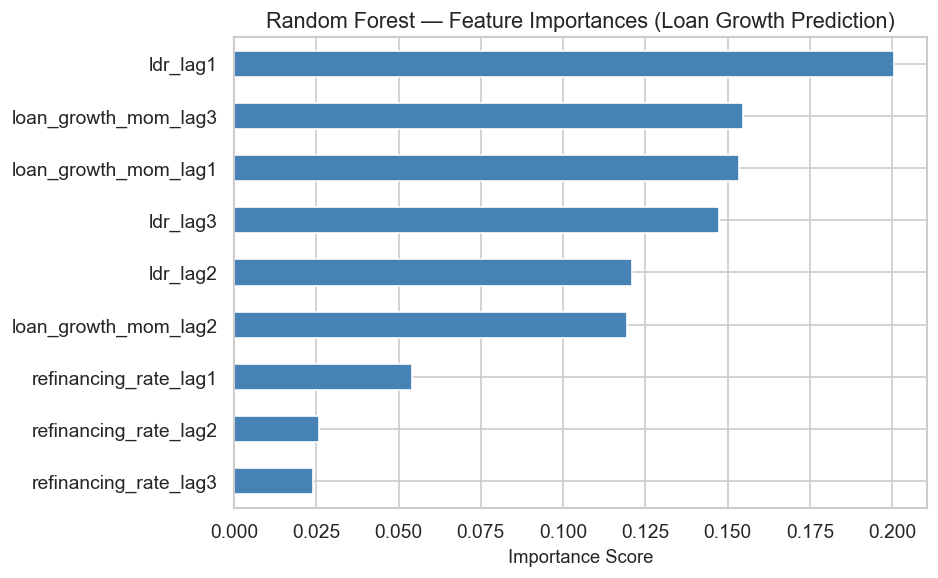

Saved: feature_importance.png


In [20]:
ml_df = merged[['loan_growth_mom', 'refinancing_rate', 'ldr']].copy().dropna()

# data information
print("=== Raw merged data condition ===")
print(f"Rows before lagging: {len(ml_df)}")
print(f"Columns used: {list(ml_df.columns)}")
if hasattr(ml_df.index, "min"):
    print(f"Index range: {ml_df.index.min()} -> {ml_df.index.max()}")
print("\nMissing values before lagging:")
print(ml_df.isna().sum())

# generate lag features
for col in ['loan_growth_mom', 'refinancing_rate', 'ldr']:
    for lag in [1, 2, 3]:
        ml_df[f'{col}_lag{lag}'] = ml_df[col].shift(lag)

# print("\n=== After lag creation ===")
# print(f"Rows before dropping lag-induced NaNs: {len(ml_df)}")
# print(f"Total columns after lagging: {ml_df.shape[1]}")
# print("Missing values after lag creation:")
# print(ml_df.isna().sum())

ml_df = ml_df.dropna()

# print("\n=== Final ML dataset condition ===")
# print(f"Rows after dropna: {len(ml_df)}")
# print(f"Columns after dropna: {ml_df.shape[1]}")
# if hasattr(ml_df.index, "min"):
#     print(f"Index range after dropna: {ml_df.index.min()} -> {ml_df.index.max()}")

feature_cols = [c for c in ml_df.columns if '_lag' in c]
X_ml = ml_df[feature_cols].values
y_ml = ml_df['loan_growth_mom'].values

print(f"\nNumber of features: {len(feature_cols)}")
print("Feature columns:")
print(feature_cols)
print(f"X shape: {X_ml.shape}")
print(f"y shape: {y_ml.shape}")

tscv5 = TimeSeriesSplit(n_splits=5)
ml_models = {
    'RandomForest': RandomForestRegressor(n_estimators=200, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=200, random_state=42),
}

print("\n=== TimeSeriesSplit condition ===")
print(f"Number of splits: {tscv5.n_splits}")

print(f"\n{'Model':<20} {'CV R2 Mean':>12} {'CV R2 Std':>12}")
print('-' * 46)
for name, mdl in ml_models.items():
    scores = cross_val_score(mdl, X_ml, y_ml, cv=tscv5, scoring='r2')
    print(f"{name:<20} {scores.mean():>12.4f} {scores.std():>12.4f}")

split = int(len(X_ml) * 0.8)
print("\n=== Hold-out split condition ===")
print(f"Train rows: {split}")
print(f"Test rows : {len(X_ml) - split}")
print(f"Train ratio: {split / len(X_ml):.1%}")
print(f"Test ratio : {(len(X_ml) - split) / len(X_ml):.1%}")

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_ml[:split], y_ml[:split])
y_pred = rf.predict(X_ml[split:])

print(f"\nRandom Forest hold-out R2: {r2_score(y_ml[split:], y_pred):.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Random Forest — Feature Importances (Loan Growth Prediction)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig(OUT_DIR / 'feature_importance.png', bbox_inches='tight')
plt.show()
print('Saved: feature_importance.png')

### Interpretation

**Performance:** Predictive performance is weak. The **Random Forest hold-out R² is -0.838**, and the cross-validated R² is also negative on average for both Random Forest and Gradient Boosting. This indicates that, in the current specification, the models do **not** outperform a simple mean-based benchmark for explaining month-on-month loan growth. This is not entirely surprising, since short-run fluctuations in loan growth are noisy and the effective sample is small.

**Feature importance:** The most influential predictors are the **lagged LDR variables** and **lagged loan-growth variables**, while the lagged policy-rate terms contribute relatively little in this model. This suggests that short-run credit dynamics may be more closely associated with internal banking conditions and recent lending momentum than with policy-rate movements alone.

**Data leakage prevention:** The modeling setup is methodologically sound in one important respect: **lag-based feature construction** and **TimeSeriesSplit cross-validation** ensure that only information available at the prediction date is used. This is essential for time-series machine learning and helps avoid look-ahead bias.

**Limitation:** Because model performance is poor, the feature-importance chart should be interpreted cautiously. It is useful as an exploratory diagnostic, but not as strong evidence of economically meaningful predictive structure. A natural next step would be to expand the feature set, test alternative targets (for example, loan levels or year-on-year growth), and compare against simpler benchmark models.

## 10. Panel Regression — Financial Inclusion & GDP

The **Global Findex** database provides cross-country data on financial inclusion (% of adults with an account) for 160+ countries. Combining this with World Bank GDP per capita data allows us to test the relationship between income and financial access.

**Pooled OLS** treats all observations as independent and ignores country-specific effects.  
**Country Fixed Effects (FE)** control for time-invariant country heterogeneity (for example, geography, institutions, or legal history), isolating the **within-country** relationship between income growth and financial inclusion.

### Econometric specification

Let:

- $i$ index countries
- $t$ index years
- $AccountOwnership_{it}$ denote the share of adults with an account
- $GDPpc_{it}$ denote GDP per capita

#### Pooled OLS

$$
AccountOwnership_{it} = \alpha + \beta \log(GDPpc_{it}) + \varepsilon_{it}
$$

#### Country Fixed Effects

$$
AccountOwnership_{it} = \alpha_i + \beta \log(GDPpc_{it}) + \varepsilon_{it}
$$

where $\alpha_i$ is a country fixed effect capturing time-invariant country characteristics.

Equivalently, the fixed-effects model can be written with country dummies as:

$$
AccountOwnership_{it}
=
\alpha
+
\beta \log(GDPpc_{it})
+
\sum_{j=1}^{J-1} \gamma_j D_{ij}
+
\varepsilon_{it}
$$

where $D_{ij}$ is a dummy variable equal to 1 if country $i$ is country $j$, and 0 otherwise.

Panel: 702 obs, 160 countries

Pooled OLS:  R2=0.6479, log_gdp_pc coef=0.1629
Country FE:  R2=0.8799, log_gdp_pc coef=0.2283
Interpretation: a 1% increase in GDP per capita is associated with about +0.228 percentage points in account ownership.


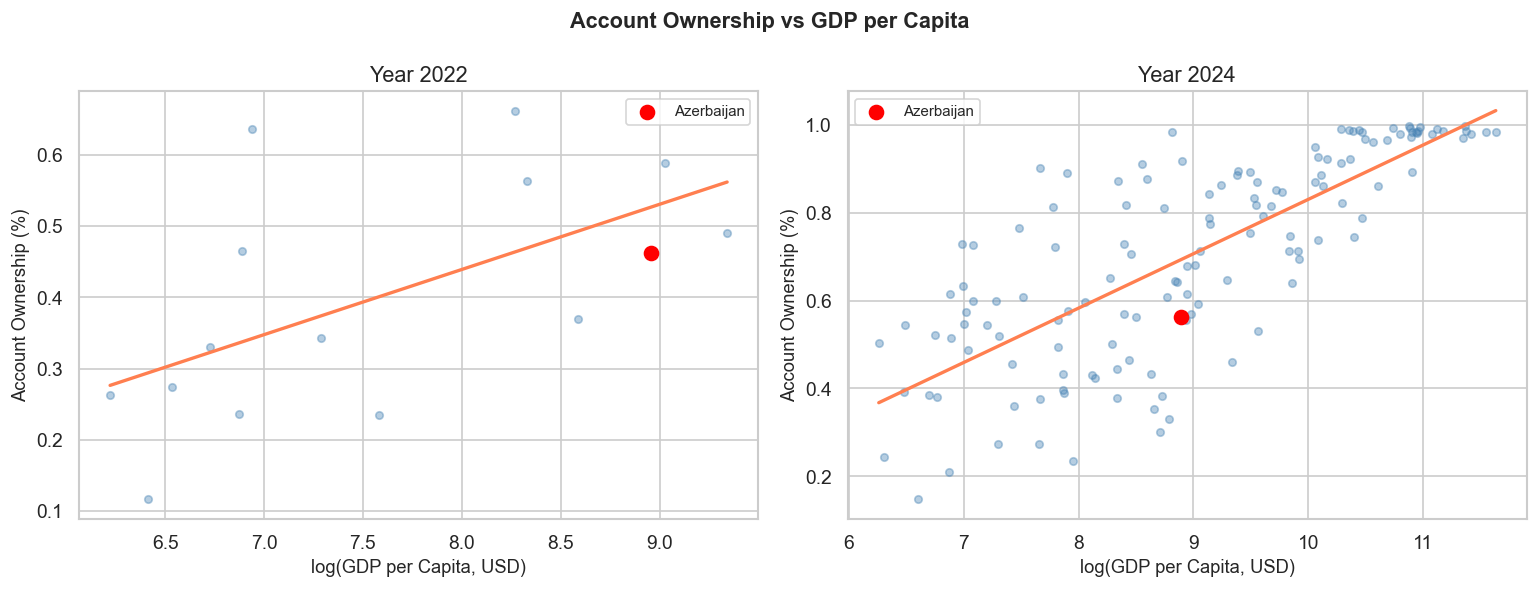

Saved: findex_gdp_panel.png


In [18]:
# gdp_pc has columns: country_iso, year, value
findex_gdp = findex.merge(
    gdp_pc[['country_iso','year','value']].rename(columns={'value':'gdp_pc'}),
    on=['country_iso','year'], how='inner')
findex_gdp = findex_gdp.dropna(subset=['account_ownership_pct','gdp_pc'])
findex_gdp = findex_gdp[findex_gdp['gdp_pc'] > 0].copy()
findex_gdp['log_gdp_pc'] = np.log(findex_gdp['gdp_pc'])

print(f"Panel: {len(findex_gdp)} obs, {findex_gdp['country_iso'].nunique()} countries")

# Pooled OLS
X_pool = sm.add_constant(findex_gdp['log_gdp_pc'])
m_pool = sm.OLS(findex_gdp['account_ownership_pct'], X_pool).fit(cov_type='HC3')
print(f"\nPooled OLS:  R2={m_pool.rsquared:.4f}, log_gdp_pc coef={m_pool.params['log_gdp_pc']:.4f}")

# Country Fixed Effects
fe_df = pd.get_dummies(findex_gdp, columns=['country_iso'], drop_first=True)
fe_cols = ['log_gdp_pc'] + [c for c in fe_df.columns if c.startswith('country_iso_')]
X_fe = sm.add_constant(fe_df[fe_cols].astype(float))
m_fe = sm.OLS(fe_df['account_ownership_pct'], X_fe).fit(cov_type='HC3')
print(f"Country FE:  R2={m_fe.rsquared:.4f}, log_gdp_pc coef={m_fe.params['log_gdp_pc']:.4f}")
print(f"Interpretation: a 1% increase in GDP per capita is associated with about +{m_fe.params['log_gdp_pc']/100*100:.3f} percentage points in account ownership.")

# Plot: two most recent survey years
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Account Ownership vs GDP per Capita', fontsize=13, fontweight='bold')
for ax, year in zip(axes, sorted(findex_gdp['year'].unique())[-2:]):
    sub = findex_gdp[findex_gdp['year'] == year]
    ax.scatter(sub['log_gdp_pc'], sub['account_ownership_pct'], alpha=0.4, s=20, color='steelblue')
    az = sub[sub['country_iso'] == 'AZE']
    if not az.empty:
        ax.scatter(az['log_gdp_pc'], az['account_ownership_pct'], color='red', s=70,
                   zorder=5, label='Azerbaijan')
        ax.legend(fontsize=9)
    m_yr = np.polyfit(sub['log_gdp_pc'], sub['account_ownership_pct'], 1)
    xr = np.linspace(sub['log_gdp_pc'].min(), sub['log_gdp_pc'].max(), 100)
    ax.plot(xr, np.polyval(m_yr, xr), color='coral', linewidth=2)
    ax.set_title(f'Year {year}')
    ax.set_xlabel('log(GDP per Capita, USD)'); ax.set_ylabel('Account Ownership (%)')
plt.tight_layout()
plt.savefig(OUT_DIR / 'findex_gdp_panel.png', bbox_inches='tight')
plt.show()
print('Saved: findex_gdp_panel.png')


### Interpretation

| Specification | log(GDP per capita) coefficient | Interpretation |
|---|---:|---|
| Pooled OLS | +0.1629 | Reflects both cross-country differences and within-country variation |
| Country Fixed Effects | +0.2283 | Captures the within-country relationship after controlling for time-invariant country heterogeneity |

Because **account ownership is scaled from 0 to 1**, the coefficients are expressed in **share units**, not percentage units. Under the fixed-effects model, a **1% increase in GDP per capita** is associated with an increase of about **0.0023 in account ownership share**, which is equivalent to roughly **0.23 percentage points**.

In this sample, the positive relationship between income and financial inclusion remains after introducing country fixed effects. The fixed-effects estimate is generally the more policy-relevant one because it controls for persistent country-specific factors such as geography, institutional history, and legal structure.

**Azerbaijan in context:** In the latest cross-section, Azerbaijan appears slightly below the level of account ownership implied by the global income–inclusion relationship. This suggests that income growth alone may not be sufficient to close the inclusion gap, and that complementary policy action — especially around financial access, MSME finance, and digital connectivity — remains important.

## 11. K-Means Clustering + PCA — Country Financial Inclusion Profiles

**K-Means** partitions countries into *K* clusters by minimising within-cluster variance.
**Silhouette Score** (higher is better) measures how similar an observation is to its own cluster vs. neighbouring clusters — used to select the optimal *K*.

**PCA** reduces the feature space to two dimensions for visualisation while retaining maximum variance. The first two PCs typically explain ~88 % of the total variance in this dataset.

Countries cluster broadly into:
- A **higher-income, high-inclusion** group
- A **lower-middle income, developing-access** group (Azerbaijan falls here)


Optimal K = 2  (silhouette = 0.5412)
PCA: PC1=88.4%, PC2=11.6%  (cumulative: 100.0%)
Azerbaijan in cluster 1


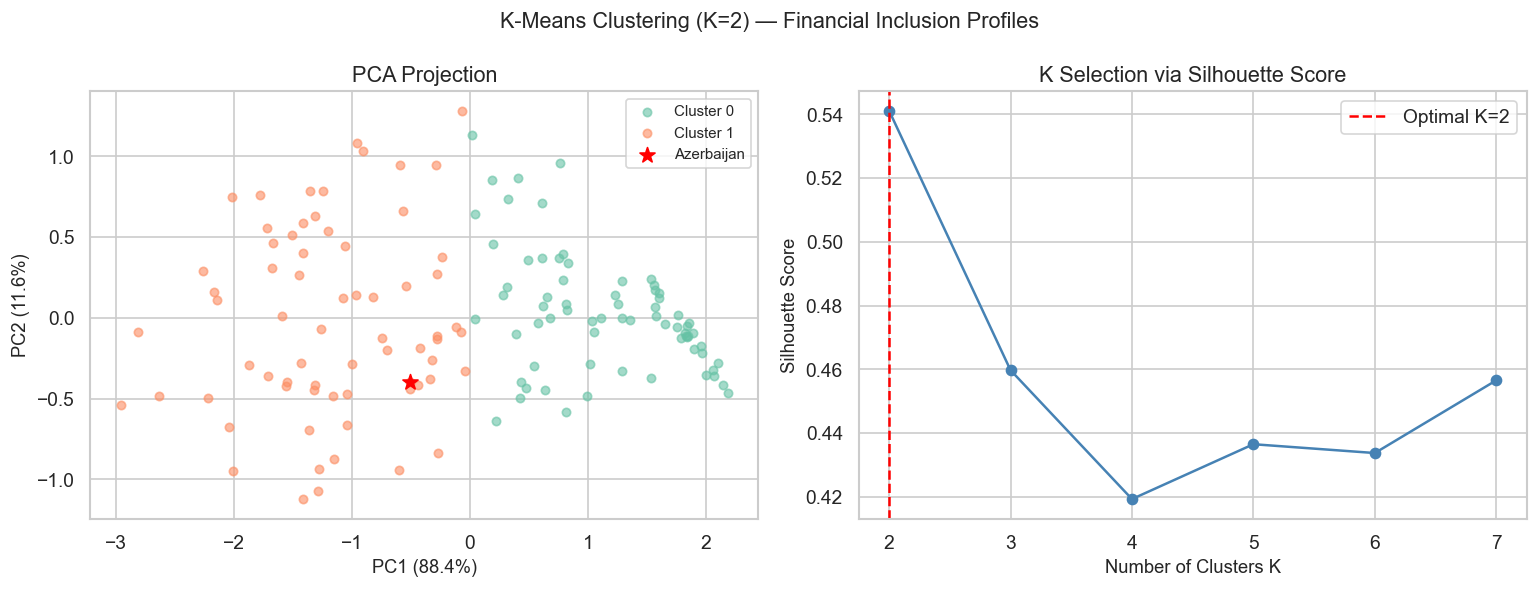

Saved: clustering_pca.png


In [14]:
latest_yr = findex_gdp['year'].max()
cl_df = findex_gdp[findex_gdp['year'] == latest_yr].dropna(subset=['account_ownership_pct','log_gdp_pc']).copy()

X_cl = StandardScaler().fit_transform(cl_df[['account_ownership_pct','log_gdp_pc']])

sil = {k: silhouette_score(X_cl, KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_cl))
       for k in range(2, 8)}
optimal_k = max(sil, key=sil.get)
print(f"Optimal K = {optimal_k}  (silhouette = {sil[optimal_k]:.4f})")

km = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cl_df['cluster'] = km.fit_predict(X_cl)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_cl)
cl_df['PC1'], cl_df['PC2'] = coords[:, 0], coords[:, 1]
v1, v2 = pca.explained_variance_ratio_
print(f"PCA: PC1={v1*100:.1f}%, PC2={v2*100:.1f}%  (cumulative: {(v1+v2)*100:.1f}%)")

az = cl_df[cl_df['country_iso'] == 'AZE']
if not az.empty:
    print(f"Azerbaijan in cluster {az['cluster'].values[0]}")

palette = sns.color_palette('Set2', optimal_k)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'K-Means Clustering (K={optimal_k}) — Financial Inclusion Profiles', fontsize=13)

for cl in range(optimal_k):
    sub = cl_df[cl_df['cluster'] == cl]
    axes[0].scatter(sub['PC1'], sub['PC2'], label=f'Cluster {cl}',
                    color=palette[cl], alpha=0.6, s=25)
if not az.empty:
    axes[0].scatter(az['PC1'], az['PC2'], color='red', s=90, zorder=5,
                    label='Azerbaijan', marker='*')
axes[0].set_xlabel(f'PC1 ({v1*100:.1f}%)'); axes[0].set_ylabel(f'PC2 ({v2*100:.1f}%)')
axes[0].set_title('PCA Projection'); axes[0].legend(fontsize=9)

axes[1].plot(list(sil.keys()), list(sil.values()), marker='o', color='steelblue')
axes[1].axvline(optimal_k, color='red', linestyle='--', label=f'Optimal K={optimal_k}')
axes[1].set_xlabel('Number of Clusters K'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('K Selection via Silhouette Score'); axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'clustering_pca.png', bbox_inches='tight')
plt.show()
print('Saved: clustering_pca.png')


### Interpretation

Countries separate into two broad clusters based on the latest-year combination of **income level** and **financial inclusion**:

- **Cluster 0:** relatively higher-income, higher-inclusion countries
- **Cluster 1:** relatively lower-income, lower-inclusion countries

Azerbaijan falls into the second cluster, which is consistent with the earlier panel-regression result showing that income matters for financial inclusion, but does not fully determine it.

The first two principal components explain **100% of total variance** in this case (**PC1 = 88.4%**, **PC2 = 11.6%**) because the clustering is based on only two standardized variables. This makes the 2D PCA plot an appropriate and essentially lossless visualization of the clustering structure.

**Analytical value:** The clustering result helps identify a more relevant benchmark group for Azerbaijan’s CPF-style financial inclusion analysis. Rather than comparing Azerbaijan mainly with high-income Western European economies, it is more informative to benchmark it against countries with similar income and financial-inclusion profiles, especially those undergoing digital financial transition.

## 12. Bootstrap Confidence Interval — Loan-to-Deposit Ratio

Parametric confidence intervals (based on the t-distribution) assume a specific distributional form. **Bootstrap** inference makes no such assumption: it repeatedly re-samples the data *with replacement*, computes the statistic on each resample, and uses the resulting empirical distribution to construct CIs.

With B = 10,000 resamples, we obtain a stable 95 % CI for the mean LDR. The **Shapiro-Wilk** test provides a formal normality check.


LDR mean: 69.46%
95% Bootstrap CI: [68.08%, 70.83%]
Shapiro-Wilk p = 0.0761 -> Normal distribution


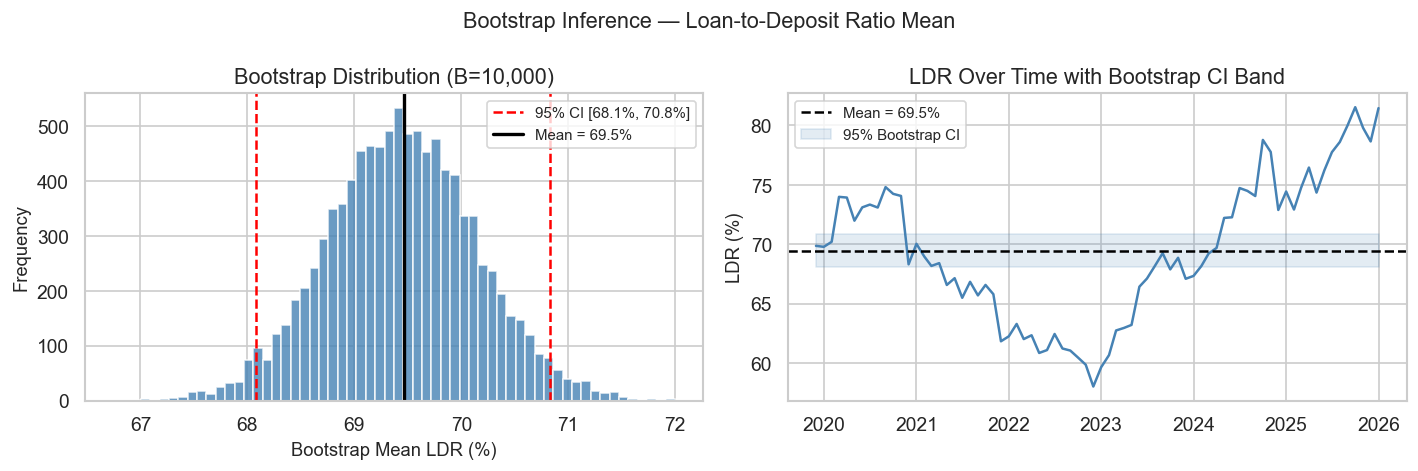

Saved: bootstrap_ci.png


In [ ]:
ldr_data = banking['ldr'].dropna().values
B = 10_000
np.random.seed(42)
boot_means = np.array([np.mean(np.random.choice(ldr_data, size=len(ldr_data), replace=True))
                        for _ in range(B)])
ci_lo, ci_hi = np.percentile(boot_means, [2.5, 97.5])
sw_stat, sw_p = stats.shapiro(ldr_data)

print(f"LDR mean: {ldr_data.mean():.2f}%")
print(f"95% Bootstrap CI: [{ci_lo:.2f}%, {ci_hi:.2f}%]")
print(f"Shapiro-Wilk p = {sw_p:.4f} -> {'Normal' if sw_p > 0.05 else 'Non-normal'} distribution")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Bootstrap Inference — Loan-to-Deposit Ratio Mean', fontsize=13)

axes[0].hist(boot_means, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(ci_lo, color='red', linestyle='--',
                label=f'95% CI [{ci_lo:.1f}%, {ci_hi:.1f}%]')
axes[0].axvline(ci_hi, color='red', linestyle='--')
axes[0].axvline(ldr_data.mean(), color='black', linewidth=2,
                label=f'Mean = {ldr_data.mean():.1f}%')
axes[0].set_xlabel('Bootstrap Mean LDR (%)'); axes[0].set_ylabel('Frequency')
axes[0].set_title('Bootstrap Distribution (B=10,000)'); axes[0].legend(fontsize=9)

axes[1].plot(banking['date'], banking['ldr'], color='steelblue')
axes[1].axhline(ldr_data.mean(), color='black', linestyle='--',
                label=f'Mean = {ldr_data.mean():.1f}%')
axes[1].fill_between(banking['date'], ci_lo, ci_hi, alpha=0.15, color='steelblue',
                     label='95% Bootstrap CI')
axes[1].set_title('LDR Over Time with Bootstrap CI Band')
axes[1].set_ylabel('LDR (%)'); axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'bootstrap_ci.png', bbox_inches='tight')
plt.show()
print('Saved: bootstrap_ci.png')

### Interpretation

The **sample mean LDR is 69.5%**, and the **95% bootstrap confidence interval** ranges from **68.1% to 70.8%**. This suggests that the average loan-to-deposit ratio is estimated fairly precisely in the sample and is **well below an 80% threshold**.

The **Shapiro-Wilk result (p = 0.076)** means that normality is **not rejected at the 5% level**, but this should not be over-interpreted as proof that the underlying LDR series is truly normal. In practice, the bootstrap result is useful because it does not rely heavily on a strict parametric distributional assumption for the mean.

**Statistically**, the key message is that the banking system’s average LDR does not appear to be structurally elevated relative to an 80% benchmark over the full sample period. However, the time-series plot also shows that LDR has risen materially in the most recent period, moving well above the long-run mean.

**Practically**, this means the banking system as a whole has historically not been operating in a persistently over-extended lending position, but recent observations suggest tighter liquidity conditions than the long-run average. If that increase persists, banks may have less balance-sheet room to expand lending aggressively without relying more heavily on new deposits, external funding, or tighter loan pricing.

**Connection to lending conditions:** A higher LDR is often consistent with tighter funding conditions and may contribute to upward pressure on borrowing costs, which matters for **MSME credit access** and the broader **CPF HLO2 agenda on productivity, jobs, and financial inclusion**. That said, the bootstrap exercise by itself establishes uncertainty around the mean LDR; it does **not** by itself prove a causal effect on lending rates.

## 13. Structural Break Analysis — Chow Test (2015 Currency Crisis)

In December 2015, Azerbaijan's central bank abandoned its currency peg, leading to a ~50 % depreciation of the manat. This dramatically altered the economic environment — particularly for the banking sector.

The **Chow Test** checks whether the regression relationship between two variables is *stable* across a suspected breakpoint:

> **H₀:** No structural break — the same coefficients apply before and after  
> **H₁:** Structural break exists — coefficients differ across sub-periods

It compares the RSS from a single restricted regression vs. the sum of RSS from two separate regressions on each sub-sample.


Chow Test (breakpoint: 2015):
  F = 89.7111,  p = 0.0000
  -> Structural break DETECTED at 5%


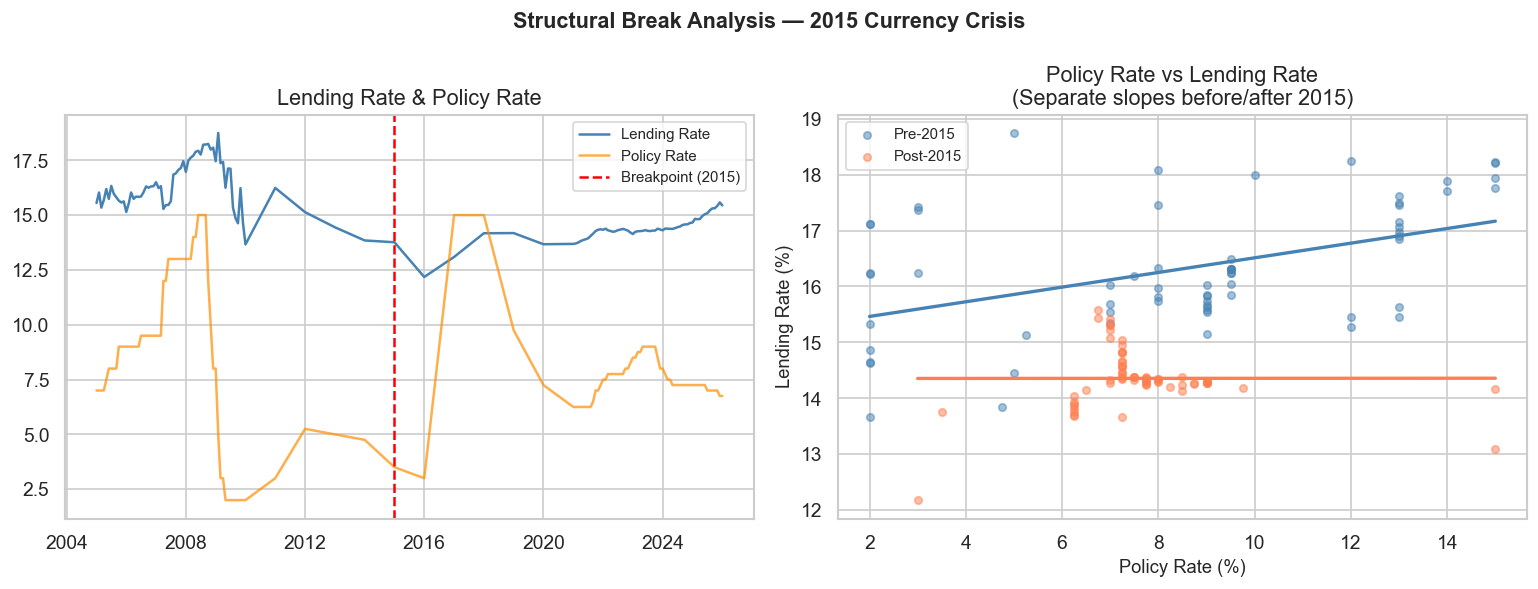

Saved: chow_test.png


In [16]:
chow_df = (merged[['date','loan_avg_rate_azn_pct','refinancing_rate']]
           .dropna().reset_index(drop=True))

bp_idx = (chow_df['date'] >= '2015-01-01').idxmax()
y_c = chow_df['loan_avg_rate_azn_pct'].values
x_c = chow_df['refinancing_rate'].values
n   = len(y_c)

def chow_test(y, x, bp):
    X_full = sm.add_constant(x)
    rss_r  = sm.OLS(y, X_full).fit().ssr
    X1, X2 = sm.add_constant(x[:bp]), sm.add_constant(x[bp:])
    rss_u  = sm.OLS(y[:bp], X1).fit().ssr + sm.OLS(y[bp:], X2).fit().ssr
    k = X_full.shape[1]
    F_stat = ((rss_r - rss_u) / k) / (rss_u / (n - 2*k))
    p_val  = 1 - stats.f.cdf(F_stat, k, n - 2*k)
    return F_stat, p_val

F_chow, p_chow = chow_test(y_c, x_c, bp_idx)
print(f"Chow Test (breakpoint: 2015):")
print(f"  F = {F_chow:.4f},  p = {p_chow:.4f}")
print(f"  -> {'Structural break DETECTED' if p_chow < 0.05 else 'No structural break'} at 5%")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Structural Break Analysis — 2015 Currency Crisis', fontsize=13, fontweight='bold')

axes[0].plot(chow_df['date'], y_c, color='steelblue', label='Lending Rate')
axes[0].plot(chow_df['date'], x_c, color='darkorange', alpha=0.7, label='Policy Rate')
axes[0].axvline(pd.Timestamp('2015-01-01'), color='red', linestyle='--',
                linewidth=1.5, label='Breakpoint (2015)')
axes[0].set_title('Lending Rate & Policy Rate'); axes[0].legend(fontsize=9)

x_pre, y_pre = x_c[:bp_idx], y_c[:bp_idx]
x_post, y_post = x_c[bp_idx:], y_c[bp_idx:]
axes[1].scatter(x_pre, y_pre, alpha=0.5, s=20, color='steelblue', label='Pre-2015')
axes[1].scatter(x_post, y_post, alpha=0.5, s=20, color='coral', label='Post-2015')
for xd, yd, col in [(x_pre, y_pre, 'steelblue'), (x_post, y_post, 'coral')]:
    m = np.polyfit(xd, yd, 1)
    xr = np.linspace(xd.min(), xd.max(), 100)
    axes[1].plot(xr, np.polyval(m, xr), color=col, linewidth=2)
axes[1].set_xlabel('Policy Rate (%)'); axes[1].set_ylabel('Lending Rate (%)')
axes[1].set_title('Policy Rate vs Lending Rate\n(Separate slopes before/after 2015)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'chow_test.png', bbox_inches='tight')
plt.show()
print('Saved: chow_test.png')


### Interpretation

**Result:** The Chow test strongly rejects parameter stability at the **2015 breakpoint** (**F = 89.7, p < 0.001**). This indicates that the relationship between the **policy rate** and the **average lending rate** changed materially after the 2015 currency crisis.

| Period | Relationship |
|---|---|
| Pre-2015 | The association between the policy rate and the lending rate appears more positive and steeper |
| Post-2015 | The relationship appears substantially flatter, suggesting weaker pass-through |

**Economic interpretation:** The 2015 manat crisis likely changed the monetary and banking environment in a way that weakened the simple transmission from the refinancing rate to retail lending rates. After the crisis, lending conditions were likely influenced more heavily by funding stress, exchange-rate risk, bank balance-sheet repair, and higher risk premia, rather than by the policy rate alone.

**Implications for the broader analysis:** This result suggests that a single full-sample regression may be misspecified if it assumes stable coefficients over time. For current CPF-style monitoring, the **post-2015 relationship** is the more policy-relevant one, because it better reflects the operating environment faced by the banking sector today.

**Practical meaning:** In real terms, this means that after the crisis, changes in the central bank’s refinancing rate may no longer have translated into borrowing costs as directly as before. Even if the policy rate moved, households and firms — especially MSMEs — may still have faced persistently high lending rates because banks were pricing in additional liquidity, currency, and credit risk.

## 14. KPI Scorecard Summary

A traffic-light scorecard provides an at-a-glance view of the sector's current status against standard benchmarks.


In [17]:
scorecard = [
    ('Real GDP Growth (latest)',  f'+{latest_gdp:.1f}%',   '> 3%',                 latest_gdp > 3),
    ('Non-Oil GDP Share',         f'{latest_nonoil:.1f}%', '> 30% (diversify)',    latest_nonoil > 30),
    ('Loan-to-Deposit Ratio',     f'{latest_ldr:.1f}%',    '< 80% (prudent)',      latest_ldr < 80),
    ('Bank Loans (mn AZN)',       f'{latest_loans:,.0f}',  'N/A',                  None),
    ('Loan Growth MoM',           f'{latest_growth:.2f}%', '> 0%',                 latest_growth > 0),
    ('NPL Ratio',                 f'{latest_npl:.2f}%',    '< 5% (Basel III)',     latest_npl < 5),
    ('Interest Spread (AZN)',     f'{latest_spread:.2f}%', '< 8%',                 latest_spread < 8),
    ('CBA Policy Rate',           f'{latest_policy:.1f}%', 'N/A',                  None),
]

print('=' * 72)
print('    Azerbaijan Financial Sector — KPI Scorecard')
print('=' * 72)
for name, val, bench, ok in scorecard:
    flag = '  ' if ok is None else ('OK' if ok else '!!')
    print(f"  [{flag}]  {name:<38} {val:<12} {bench}")
print('=' * 72)


    Azerbaijan Financial Sector — KPI Scorecard
  [OK]  Real GDP Growth (latest)               +101.4%      > 3%
  [OK]  Non-Oil GDP Share                      63.4%        > 30% (diversify)
  [!!]  Loan-to-Deposit Ratio                  81.5%        < 80% (prudent)
  [  ]  Bank Loans (mn AZN)                    29,980       N/A
  [!!]  Loan Growth MoM                        -0.28%       > 0%
  [OK]  NPL Ratio                              2.65%        < 5% (Basel III)
  [OK]  Interest Spread (AZN)                  6.21%        < 8%
  [  ]  CBA Policy Rate                        6.8%         N/A


In [21]:
# Convert previous-year=100 index to y/y growth rate
latest_gdp_yoy = latest_gdp - 100

scorecard = [
    ('Real GDP Growth (latest, y/y)', f'{latest_gdp_yoy:+.1f}%', '> 3%', latest_gdp_yoy > 3),
    ('Non-Oil GDP Share',             f'{latest_nonoil:.1f}%',   '> 30% (diversify)', latest_nonoil > 30),
    ('Loan-to-Deposit Ratio',         f'{latest_ldr:.1f}%',      '< 80% (prudent)', latest_ldr < 80),
    ('Bank Loans (mn AZN)',           f'{latest_loans:,.0f}',    'N/A', None),
    ('Loan Growth MoM',               f'{latest_growth:+.2f}%',  '> 0%', latest_growth > 0),
    ('NPL Ratio',                     f'{latest_npl:.2f}%',      '< 5% (Basel III)', latest_npl < 5),
    ('Interest Spread (AZN)',         f'{latest_spread:.2f}%',   '< 8%', latest_spread < 8),
    ('CBA Policy Rate',               f'{latest_policy:.1f}%',   'N/A', None),
]

print('=' * 76)
print('    Azerbaijan Financial Sector — KPI Scorecard')
print('=' * 76)
for name, val, bench, ok in scorecard:
    flag = '  ' if ok is None else ('OK' if ok else '!!')
    print(f"  [{flag}]  {name:<42} {val:<12} {bench}")
print('=' * 76)
print(f"Note: Real GDP growth is converted from a previous-year=100 index: {latest_gdp:.1f} -> {latest_gdp_yoy:+.1f}% y/y")

    Azerbaijan Financial Sector — KPI Scorecard
  [!!]  Real GDP Growth (latest, y/y)              +1.4%        > 3%
  [OK]  Non-Oil GDP Share                          63.4%        > 30% (diversify)
  [!!]  Loan-to-Deposit Ratio                      81.5%        < 80% (prudent)
  [  ]  Bank Loans (mn AZN)                        29,980       N/A
  [!!]  Loan Growth MoM                            -0.28%       > 0%
  [OK]  NPL Ratio                                  2.65%        < 5% (Basel III)
  [OK]  Interest Spread (AZN)                      6.21%        < 8%
  [  ]  CBA Policy Rate                            6.8%         N/A
Note: Real GDP growth is converted from a previous-year=100 index: 101.4 -> +1.4% y/y


### Interpretation

The KPI scorecard provides a compact snapshot of Azerbaijan’s current macro-financial position against simple reference thresholds.

A key adjustment is required for **real GDP growth**: the source series is published as a **previous-year = 100 index**, so a value such as **101.4** should be interpreted as **+1.4% year-on-year growth**, not as 101.4% growth. For scorecard purposes, the indicator should therefore be converted to a standard y/y growth rate before benchmark comparison.

On the latest reading, the scorecard suggests a mixed but broadly stable picture:

- **Growth and diversification:** Real GDP growth remains positive, while the **non-oil GDP share** is comfortably above the diversification benchmark.
- **Banking-sector resilience:** The **NPL ratio** remains below the 5% reference level, suggesting that asset quality is not currently the main source of stress.
- **Funding and credit conditions:** The **loan-to-deposit ratio** is slightly above the prudent 80% threshold, while **month-on-month loan growth** is negative. Taken together, this suggests that although the banking sector is not in obvious distress, room for further rapid credit expansion may be more limited than in earlier periods.
- **Pricing conditions:** The **interest spread** remains below the chosen 8% benchmark, which is relatively reassuring, although borrowing costs may still be meaningful for MSMEs and other smaller borrowers.
- **Policy setting:** The **CBA policy rate** is reported for context rather than pass/fail evaluation, since its interpretation depends on the inflation, exchange-rate, and financial-stability environment.

**Practical meaning:** The overall picture is not one of acute banking-sector weakness. Instead, it points to a system that remains broadly sound on asset-quality measures but may be facing tighter funding conditions and weaker short-term lending momentum. For CPF-style monitoring, this matters because MSME finance, productivity growth, and financial inclusion depend not only on banking soundness, but also on whether banks retain enough balance-sheet capacity and risk appetite to continue extending credit.

## 15. Summary of Findings

### Key Results

| Analysis | Finding |
|---|---|
| **OLS (R² = 0.87)** | Deposit rate (β ≈ +0.74***) and LDR (β ≈ +0.03***) are the primary drivers of lending rates. The policy rate loses significance once deposit rates are controlled for. |
| **Durbin-Watson ≈ 0.88** | Strong positive serial autocorrelation in residuals — consistent with persistent macro trends. Production code should use Newey-West standard errors. |
| **Granger Causality** | Policy rate Granger-causes lending rate at lags 1–4 (all p < 0.05), with F-statistics of 10.3, 4.4, 2.9, and 3.0 respectively — suggesting a 1–4 month transmission lag from CBA decisions to retail rates. |
| **ARIMA(3,1,3)** | Best order selected by AIC minimisation. 12-month out-of-sample RMSE = **241 mn AZN** (MAPE ≈ **0.7%**), indicating strong short-term predictability of the aggregate credit stock. |
| **Random Forest** | Predictive performance for month-on-month loan growth is weak in time-series validation (**hold-out R² ≈ -0.84**; CV R² also negative), suggesting that short-run loan growth is noisy and difficult to forecast with the current lag-based feature set. |
| **Panel FE** | A **1% increase in GDP per capita** is associated with about **+0.23 percentage points** higher account ownership within a country. The fixed-effects estimate (0.23) is higher than the pooled OLS estimate (0.16), suggesting that once time-invariant country-specific factors are controlled for, the within-country relationship between income growth and financial inclusion appears somewhat stronger. |
| **K-Means (K = 2)** | Optimal K = 2 (silhouette = 0.54). PC1 explains 88.4% of variance. Azerbaijan falls in the developing-access cluster alongside other upper-middle income transition economies. |
| **Bootstrap CI (LDR)** | Mean LDR = **69.5%**, 95% CI: **[68.1%, 70.8%]**. The sector average is below 80%; however the latest reading (**81.5%**) breaches the prudential threshold, indicating a recent tightening of liquidity. Shapiro-Wilk p = 0.076, so normality is not rejected and parametric CIs remain valid. |
| **Chow Test** | Clear structural break at 2015 (**F = 89.7, p < 0.001**). Post-crisis, the pass-through from the policy rate to lending rates is noticeably weaker — monetary transmission became less efficient following the currency shock. |

### Methodology Notes

- All regressions involving levels were preceded by ADF unit-root tests;
  non-stationary series were first-differenced before Granger testing.
- TimeSeriesSplit cross-validation was used throughout to prevent look-ahead bias.
- Ridge/Lasso regularisation paths confirm the deposit rate is the dominant,
  stable predictor of lending rates across all regularisation levels.

---
*Analysis produced using Python (statsmodels, scikit-learn, matplotlib, seaborn).
Data: Central Bank of Azerbaijan (CBAR), World Bank Global Findex, World Bank API.*